# Correlation Networks

This notebook builds microbial association networks for one subject.

It loads an OTU table, computes Pearson, Spearman, and Kendall correlation matrices, and creates one network for each method.

The networks are filtered with a correlation threshold and then plotted with NetworkX.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

from metagenomes_simulation.network import (
    create_correlation_matrix_parallel,
    create_network_from_correlation_matrix,
)

In [ ]:
def plot_network(G):
    pos = nx.spring_layout(G, seed=12)

    # Draw the network
    plt.figure(figsize=(10, 10))
    nx.draw_networkx(
        G,
        pos=pos,
        with_labels=False,  # Set to True if you want OTU names
        node_size=30,
        width=0.1,
    )

    plt.axis("off")
    plt.show()

In [ ]:
from pathlib import Path

subject = "69-001"
abundance_type = "relative"  # "absolute"
path_otu = rf"..\data\processed\otu_separated_by_subjects\{abundance_type}\otu{subject}.csv"
otu_path = Path("..") / "data" / "processed" / "otu_separated_by_subjects" / abundance_type / f"{subject}.csv"
otu = pd.read_csv(otu_path, index_col=0)

In [ ]:
print("Create correlation matrix Pearson")
A_pearson = create_correlation_matrix_parallel(otu, correlation_method="Pearson")

print("Create correlation matrix Spearman")

A_spearman = create_correlation_matrix_parallel(otu, correlation_method="Spearman")

print("Create correlation matrix Kendall")

A_kendall = create_correlation_matrix_parallel(otu, correlation_method="Kendall")

Create correlation matrix Pearson


In [ ]:
G_pearson = create_network_from_correlation_matrix(A_pearson, threshold=0.3)
G_spearman = create_network_from_correlation_matrix(A_spearman, threshold=0.3)
G_kendall = create_network_from_correlation_matrix(A_kendall, threshold=0.3)

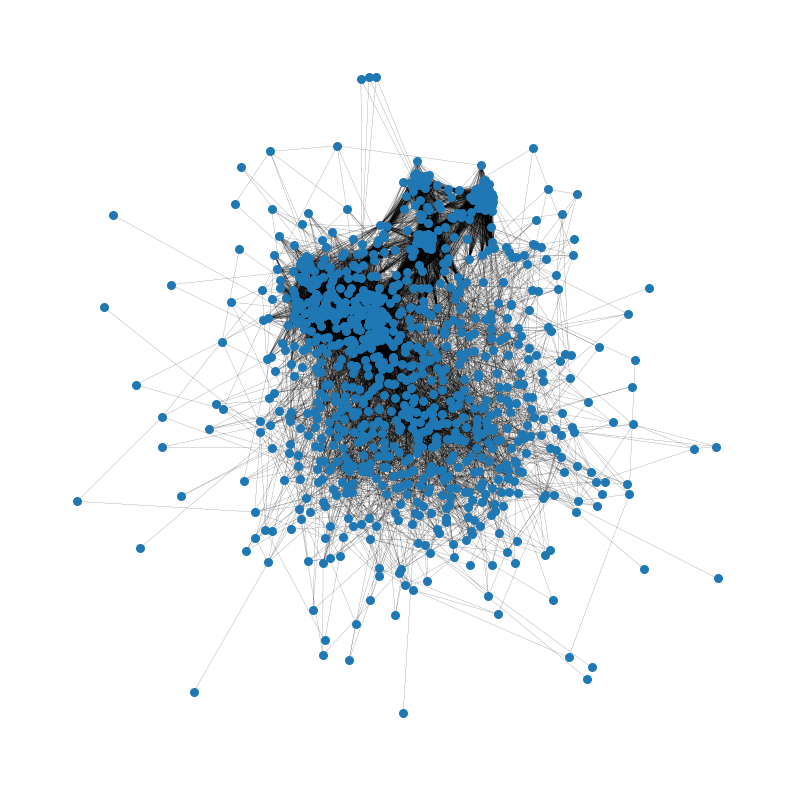

In [ ]:
plot_network(G_pearson)

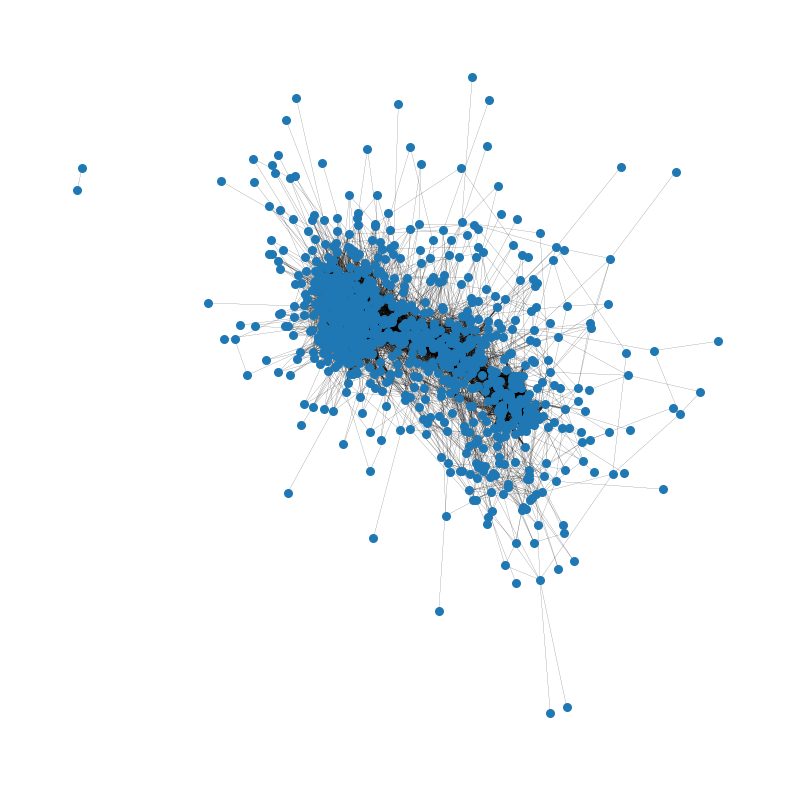

In [ ]:
plot_network(G_spearman)

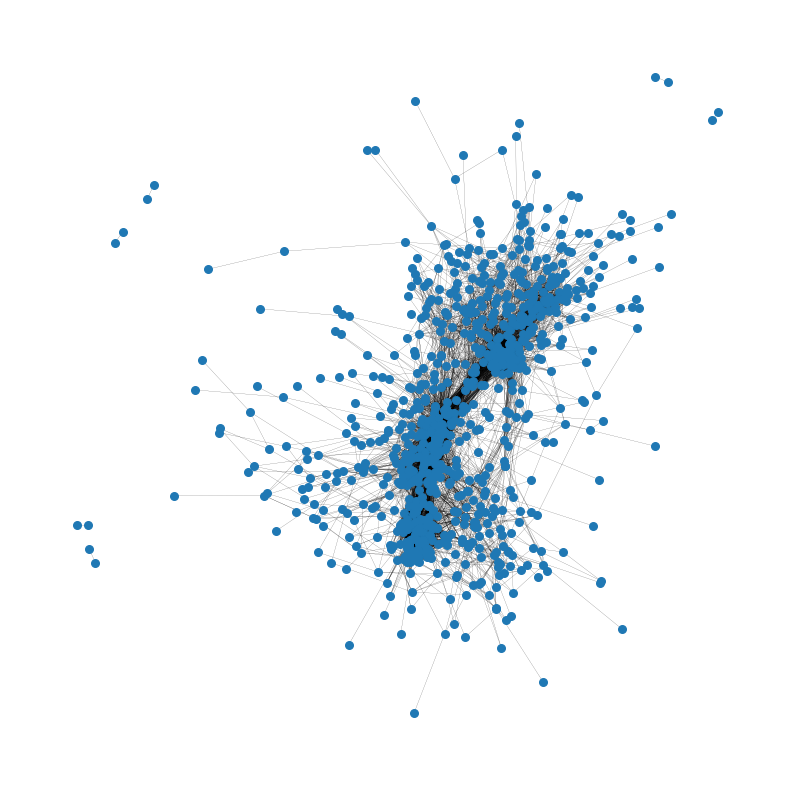

In [ ]:
plot_network(G_kendall)